## Exercise 5: Visualizing a Graph with Python

In this exercise, we go over graph data in python, and how we can make sense of it by visualizing it!




In [ ]:
%pip install networkx
import networkx
import matplotlib

Think about the types of companies that you would work in - you will always know some colleagues, but often you won't know everyone, especially if they are on other teams. If we want to find out how our relationships connect through the organization, then these types of relationships are perfect for graph data structures. Graphs are excellent for exploring the relationship between things or "nodes" - whether those are people, purchases, or transactions. Let's build a graph and see how it can visualize the relationships of coworkers.

Creating sample social graph...

Graph Info:
  Nodes: 10
  Edges: 14
Visualizing graph...
Displaying graph visualization. Close the plot window to exit.


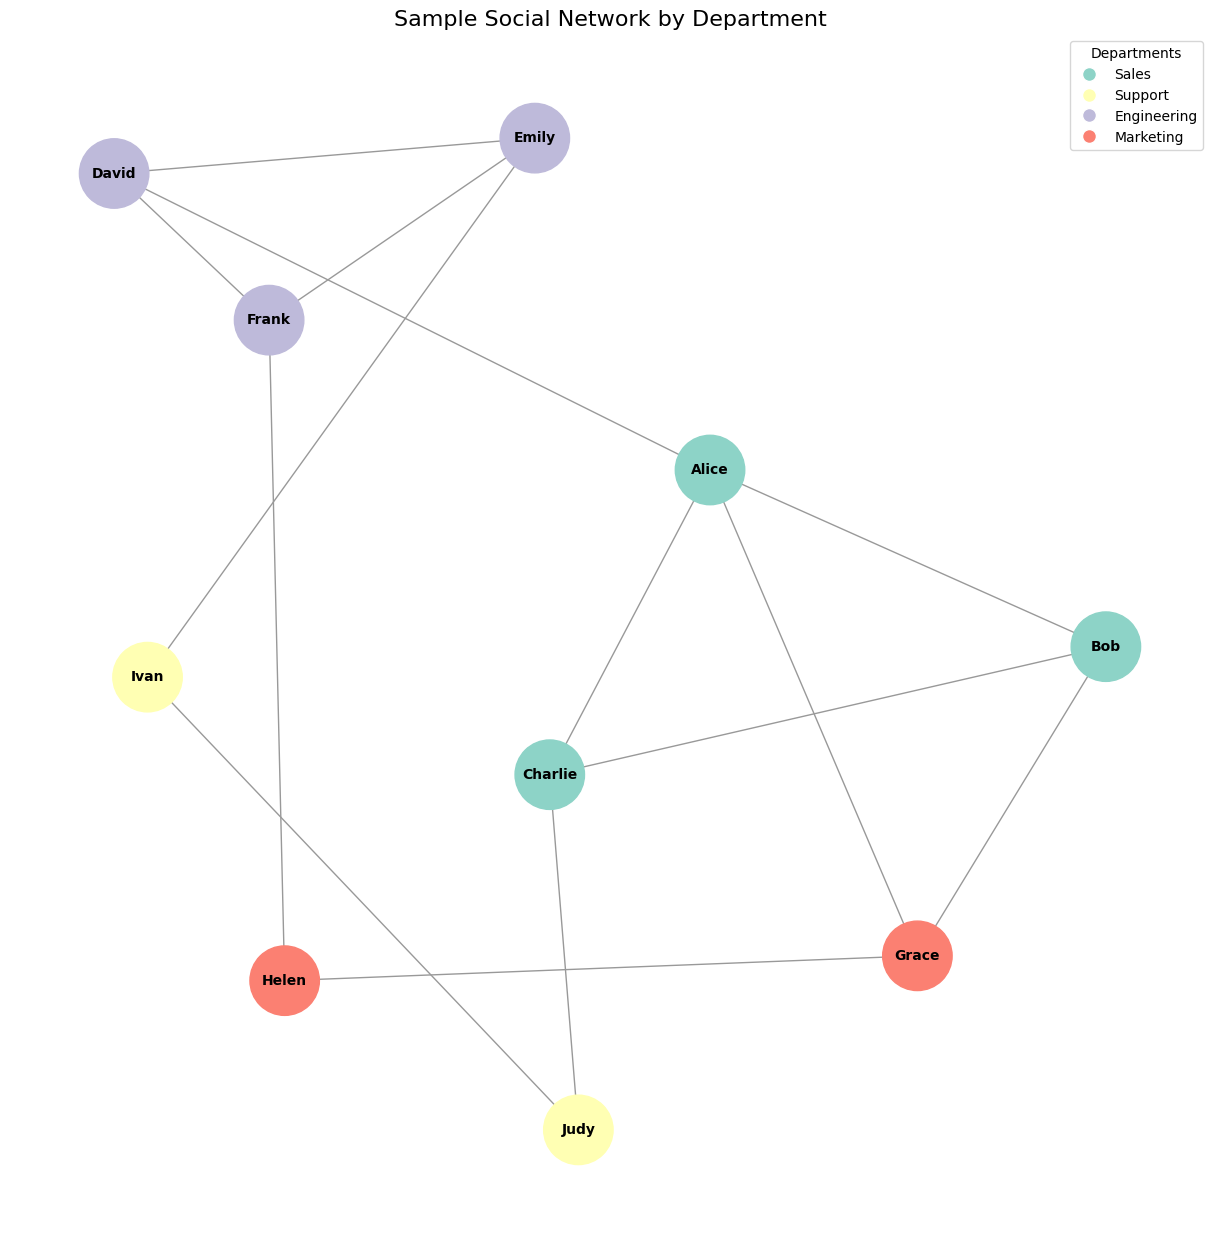

In [6]:
import networkx as nx
import matplotlib.pyplot as plt
import random

def create_social_graph():
    """
    Creates a sample social network graph using networkx.
    Nodes have a 'department' attribute for color-coding.
    """
    print("Creating sample social graph...")
    G = nx.Graph()

    # --- 1. Define Node Data (People and their department) ---
    people = [
        (1, {"name": "Alice", "department": "Sales"}),
        (2, {"name": "Bob", "department": "Sales"}),
        (3, {"name": "Charlie", "department": "Sales"}),
        (4, {"name": "David", "department": "Engineering"}),
        (5, {"name": "Emily", "department": "Engineering"}),
        (6, {"name": "Frank", "department": "Engineering"}),
        (7, {"name": "Grace", "department": "Marketing"}),
        (8, {"name": "Helen", "department": "Marketing"}),
        (9, {"name": "Ivan", "department": "Support"}),
        (10, {"name": "Judy", "department": "Support"}),
    ]

    # --- 2. Define Edge Data (Friendships/Connections) ---
    # (Node1, Node2)
    connections = [
        # Sales team
        (1, 2), (1, 3), (2, 3),
        
        # Engineering team
        (4, 5), (4, 6), (5, 6),
        
        # Marketing team
        (7, 8),
        
        # Support team
        (9, 10),
        
        # Cross-department connections
        (1, 4),  # Alice (Sales) -> David (Engineering)
        (2, 7),  # Bob (Sales) -> Grace (Marketing)
        (5, 9),  # Emily (Engineering) -> Ivan (Support)
        (6, 8),  # Frank (Engineering) -> Helen (Marketing)
        (3, 10), # Charlie (Sales) -> Judy (Support)
        (1, 7),  # Alice (Sales) -> Grace (Marketing)
    ]

    # --- 3. Add Nodes and Edges to the Graph ---
    G.add_nodes_from(people)
    G.add_edges_from(connections)
    
    return G

def visualize_graph(G):
    """
    Visualizes the given networkx graph using matplotlib.
    Nodes are colored based on their 'department' attribute.
    """
    print("Visualizing graph...")
    
    # --- 1. Prepare for Drawing ---
    
    # Get the 'department' attribute for each node
    departments = nx.get_node_attributes(G, 'department')
    
    # Create a mapping from department name to a color
    unique_departments = list(set(departments.values()))
    colors = plt.cm.Set3(range(len(unique_departments))) # Get distinct colors
    color_map = {dept: colors[i] for i, dept in enumerate(unique_departments)}

    # Assign a color to each node based on its department
    node_colors = [color_map[departments[node]] for node in G.nodes()]

    # Get the 'name' attribute for node labels
    labels = nx.get_node_attributes(G, 'name')

    # --- 2. Create a layout ---
    # This positions the nodes in a visually appealing way.
    # 'spring_layout' pushes nodes apart like a spring.
    # 'k' adjusts spacing.
    pos = nx.spring_layout(G, k=1.5, seed=42) 
    
    # --- 3. Draw the Graph ---
    plt.figure(figsize=(12, 12))
    
    nx.draw(
        G,
        pos,
        with_labels=True,      # Show node labels
        labels=labels,         # Use the 'name' attribute as the label
        node_color=node_colors,# Use our generated color list
        node_size=2500,        # Make nodes bigger
        font_size=10,
        font_weight='bold',
        edge_color='#999999'   # Light grey for edges
    )
    
    # --- 4. Add a Legend ---
    # Create dummy plot elements for the legend
    legend_elements = [plt.Line2D([0], [0], 
                                  marker='o', 
                                  color='w', 
                                  label=dept,
                                  markerfacecolor=color, 
                                  markersize=10) 
                       for dept, color in color_map.items()]

    plt.legend(handles=legend_elements, title="Departments", loc='best')

    plt.title("Sample Social Network by Department", size=16)
    plt.axis('off') # Hide the X/Y axes
    
    # --- 5. Show the Plot ---
    print("Displaying graph visualization. Close the plot window to exit.")
    plt.show()

if __name__ == "__main__":
    graph = create_social_graph()
    
    # Optional: Print some info about the graph
    print(f"\nGraph Info:")
    print(f"  Nodes: {graph.number_of_nodes()}")
    print(f"  Edges: {graph.number_of_edges()}")
    
    visualize_graph(graph)

Let's adjust the graph. Suppose Helen has been studying hard on her Udacity nanodegree, and once she completes it, she leaves the organization for her dream job as a data modeler at a big technology company!  

Creating sample social graph...

Graph Info (Before Edit):
  Nodes: 10
  Edges: 14

Processing Helen's departure...
Node 8 (Helen) and associated connections removed.

Graph Info (After Edit):
  Nodes: 9
  Edges: 12
Visualizing graph...
Displaying graph visualization. Close the plot window to exit.


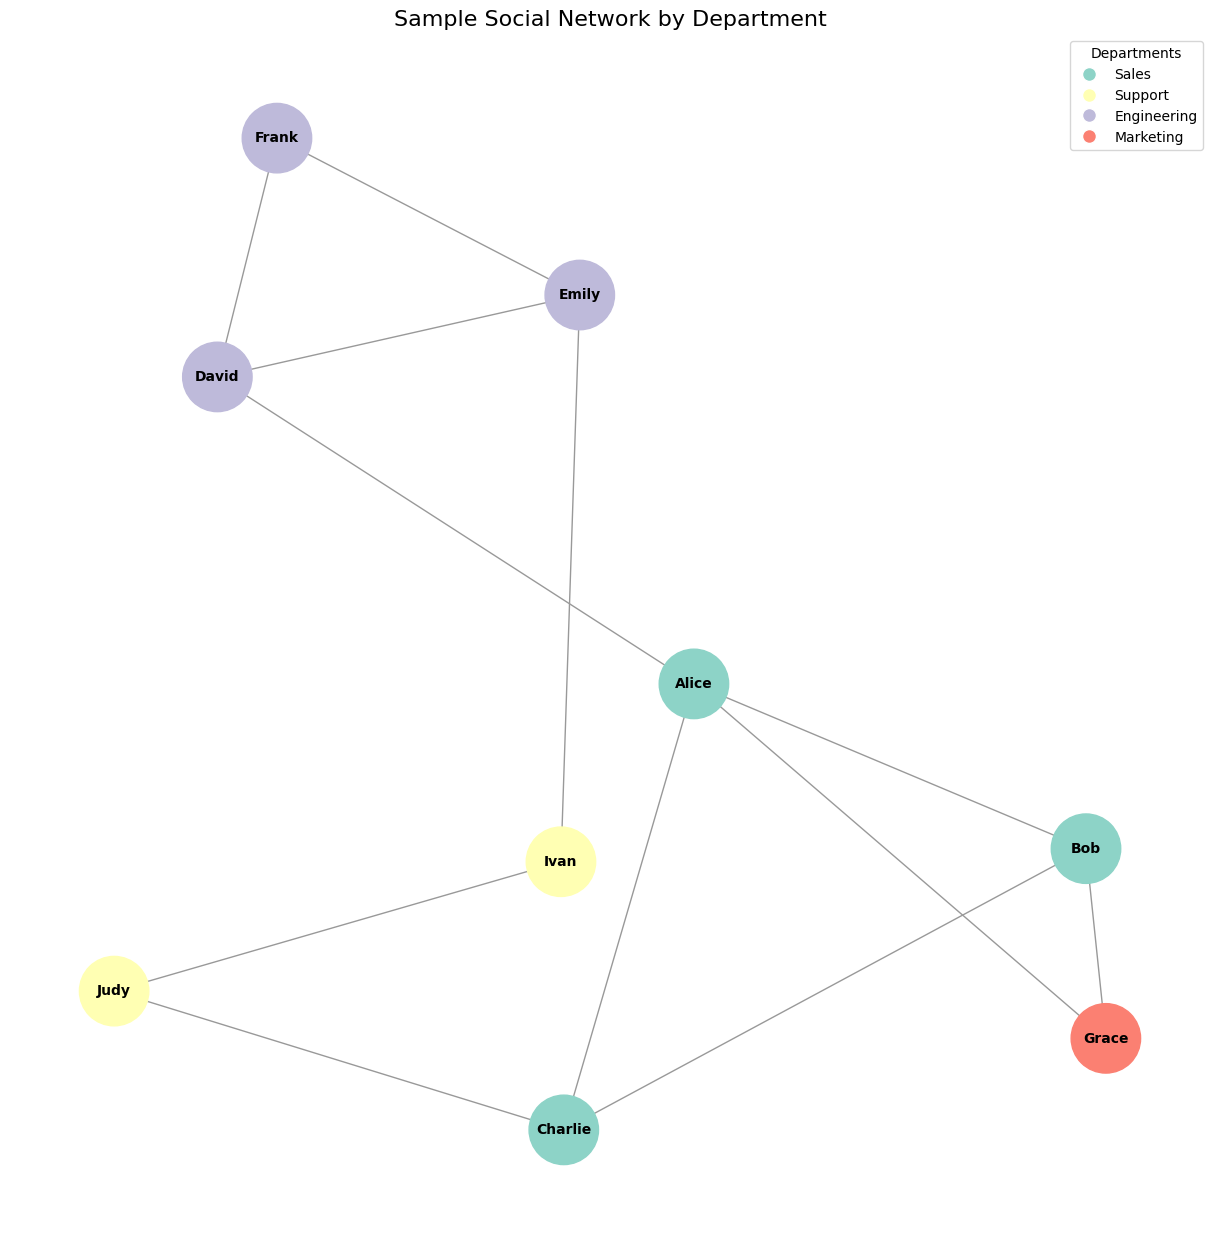

In [8]:
import networkx as nx
import matplotlib.pyplot as plt
import random

def create_social_graph():
    """
    Creates a sample social network graph using networkx.
    Nodes have a 'department' attribute for color-coding.
    """
    print("Creating sample social graph...")
    G = nx.Graph()

    # --- 1. Define Node Data (People and their department) ---
    people = [
        (1, {"name": "Alice", "department": "Sales"}),
        (2, {"name": "Bob", "department": "Sales"}),
        (3, {"name": "Charlie", "department": "Sales"}),
        (4, {"name": "David", "department": "Engineering"}),
        (5, {"name": "Emily", "department": "Engineering"}),
        (6, {"name": "Frank", "department": "Engineering"}),
        (7, {"name": "Grace", "department": "Marketing"}),
        (8, {"name": "Helen", "department": "Marketing"}),
        (9, {"name": "Ivan", "department": "Support"}),
        (10, {"name": "Judy", "department": "Support"}),
    ]

    # --- 2. Define Edge Data (Friendships/Connections) ---
    # (Node1, Node2)
    connections = [
        # Sales team
        (1, 2), (1, 3), (2, 3),
        
        # Engineering team
        (4, 5), (4, 6), (5, 6),
        
        # Marketing team
        (7, 8),
        
        # Support team
        (9, 10),
        
        # Cross-department connections
        (1, 4),  # Alice (Sales) -> David (Engineering)
        (2, 7),  # Bob (Sales) -> Grace (Marketing)
        (5, 9),  # Emily (Engineering) -> Ivan (Support)
        (6, 8),  # Frank (Engineering) -> Helen (Marketing)
        (3, 10), # Charlie (Sales) -> Judy (Support)
        (1, 7),  # Alice (Sales) -> Grace (Marketing)
    ]

    # --- 3. Add Nodes and Edges to the Graph ---
    G.add_nodes_from(people)
    G.add_edges_from(connections)
    
    return G


if __name__ == "__main__":
    graph = create_social_graph()
    
    # Optional: Print some info about the graph
    print(f"\nGraph Info (Before Edit):")
    print(f"  Nodes: {graph.number_of_nodes()}")
    print(f"  Edges: {graph.number_of_edges()}")

    # --- EDIT TO THE GRAPH ---
    # Helen (node 8) leaves the organization
    print("\nProcessing Helen's departure...")
    if 8 in graph:
        graph.remove_node(8)
        print("Node 8 (Helen) and associated connections removed.")
    else:
        print("Node 8 (Helen) not found in graph.")
    # -------------------------

    # Print info after the edit
    print(f"\nGraph Info (After Edit):")
    print(f"  Nodes: {graph.number_of_nodes()}")
    print(f"  Edges: {graph.number_of_edges()}")
    
    visualize_graph(graph)

Suppose now that Grace and Emily meet at the company dinner event and learn about each others work. Another relationship has now formed in this graph. Could you adjust the graph to add an extra connection?

Here's a hint: add the line: (5, 7)   # Emily (Sales) -> Grace (Marketing) to the correct place.

Creating sample social graph...

Graph Info (Before Edit):
  Nodes: 10
  Edges: 14

Processing Helen's departure...
Node 8 (Helen) and associated connections removed.

Graph Info (After Edit):
  Nodes: 9
  Edges: 12
Visualizing graph...
Displaying graph visualization. Close the plot window to exit.


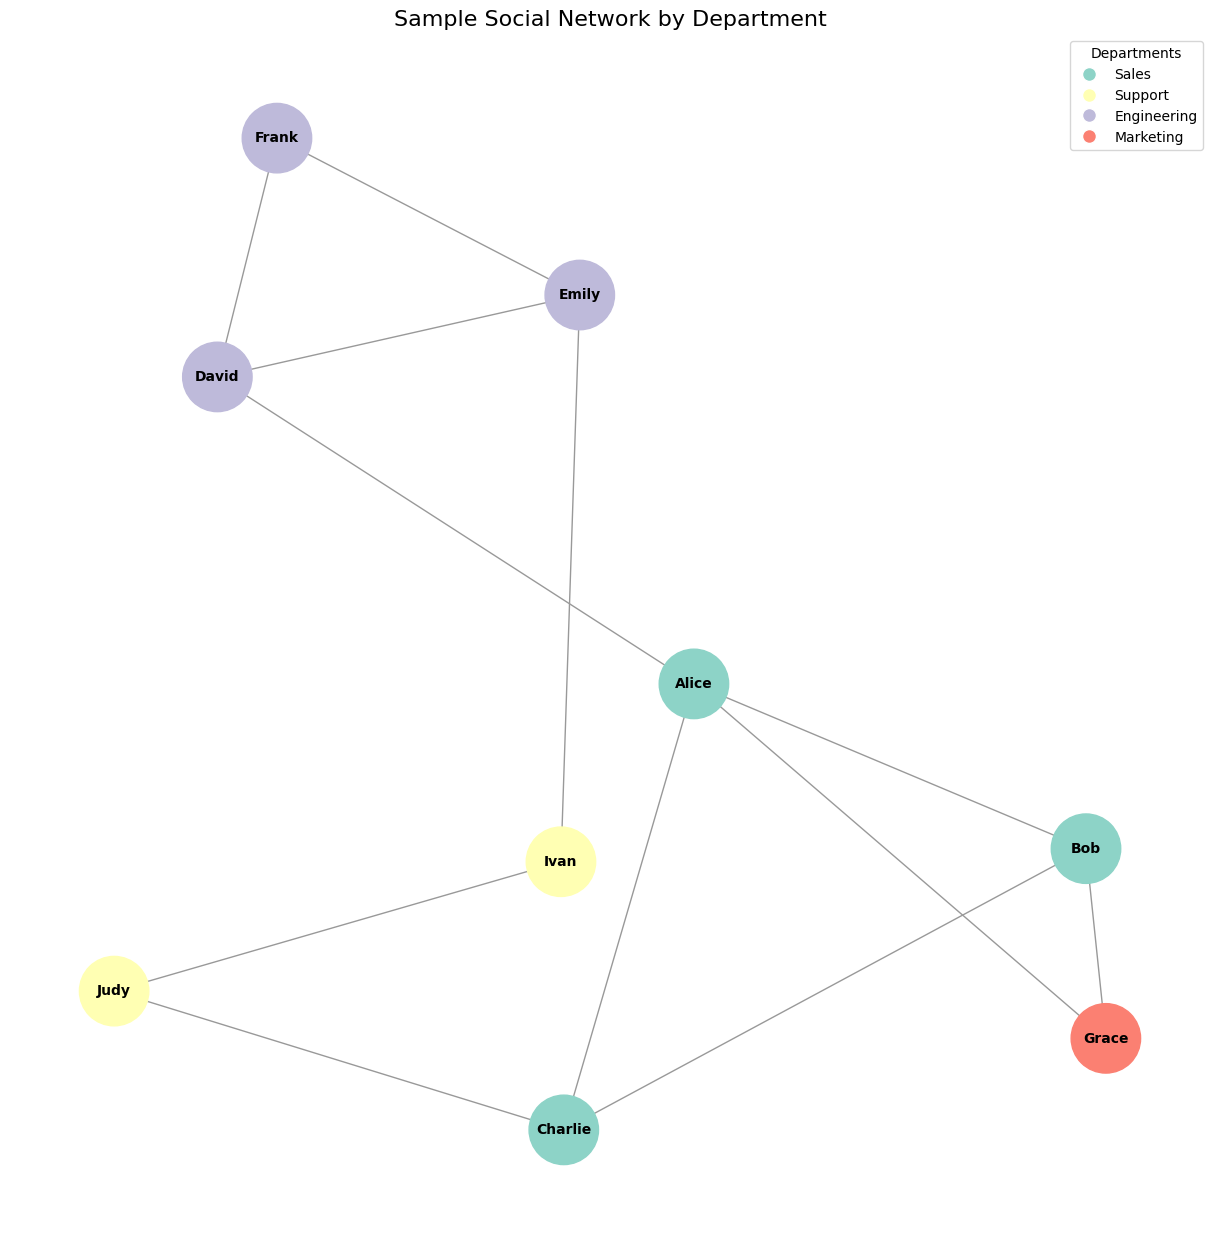

In [12]:
def create_social_graph():
    """
    Creates a sample social network graph using networkx.
    Nodes have a 'department' attribute for color-coding.
    """
    print("Creating sample social graph...")
    G = nx.Graph()

    # --- 1. Define Node Data (People and their department) ---
    people = [
        (1, {"name": "Alice", "department": "Sales"}),
        (2, {"name": "Bob", "department": "Sales"}),
        (3, {"name": "Charlie", "department": "Sales"}),
        (4, {"name": "David", "department": "Engineering"}),
        (5, {"name": "Emily", "department": "Engineering"}),
        (6, {"name": "Frank", "department": "Engineering"}),
        (7, {"name": "Grace", "department": "Marketing"}),
        (8, {"name": "Helen", "department": "Marketing"}),
        (9, {"name": "Ivan", "department": "Support"}),
        (10, {"name": "Judy", "department": "Support"}),
    ]

    # --- 2. Define Edge Data (Friendships/Connections) ---
    # (Node1, Node2)
    connections = [
        # Sales team
        (1, 2), (1, 3), (2, 3),
        
        # Engineering team
        (4, 5), (4, 6), (5, 6),
        
        # Marketing team
        (7, 8),
        
        # Support team
        (9, 10),
        
        # Cross-department connections
        (1, 4),  # Alice (Sales) -> David (Engineering)
        (2, 7),  # Bob (Sales) -> Grace (Marketing)
        (5, 9),  # Emily (Engineering) -> Ivan (Support)
        (6, 8),  # Frank (Engineering) -> Helen (Marketing)
        (3, 10), # Charlie (Sales) -> Judy (Support)
        (1, 7),  # Alice (Sales) -> Grace (Marketing)
        # Insert the relevant line!
    ]

    # --- 3. Add Nodes and Edges to the Graph ---
    G.add_nodes_from(people)
    G.add_edges_from(connections)
    
    return G


if __name__ == "__main__":
    graph = create_social_graph()
    
    # Optional: Print some info about the graph
    print(f"\nGraph Info (Before Edit):")
    print(f"  Nodes: {graph.number_of_nodes()}")
    print(f"  Edges: {graph.number_of_edges()}")

    # --- EDIT TO THE GRAPH ---
    # Helen (node 8) leaves the organization
    print("\nProcessing Helen's departure...")
    if 8 in graph:
        graph.remove_node(8)
        print("Node 8 (Helen) and associated connections removed.")
    else:
        print("Node 8 (Helen) not found in graph.")
    # -------------------------

    # Print info after the edit
    print(f"\nGraph Info (After Edit):")
    print(f"  Nodes: {graph.number_of_nodes()}")
    print(f"  Edges: {graph.number_of_edges()}")
    
    visualize_graph(graph)

Fast forward a few months. Charlie decides to take parental leave to help with his young baby. How would you remove Charlie from the graph?

Creating sample social graph...

Graph Info (Before Edit):
  Nodes: 9
  Edges: 11

Processing Helen's departure...
Node 8 (Helen) and associated connections removed.

Graph Info (After Edit):
  Nodes: 8
  Edges: 9
Visualizing graph...
Displaying graph visualization. Close the plot window to exit.


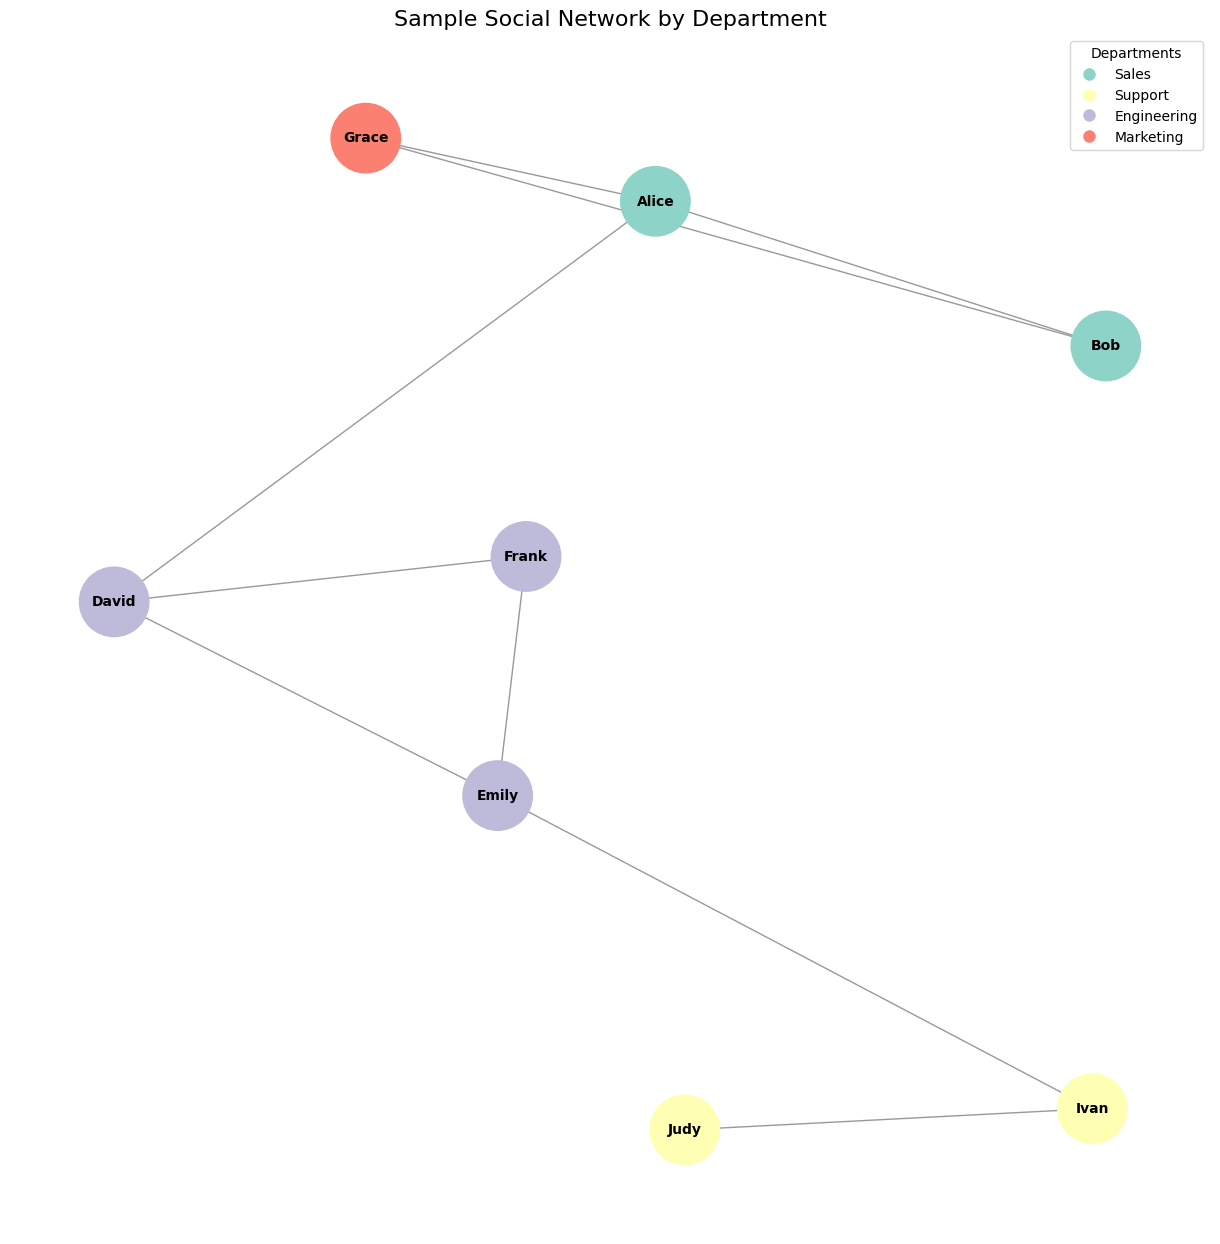

In [14]:
def create_social_graph():
    """
    Creates a sample social network graph using networkx.
    Nodes have a 'department' attribute for color-coding.
    """
    print("Creating sample social graph...")
    G = nx.Graph()

    # --- 1. Define Node Data (People and their department) ---
    people = [
        (1, {"name": "Alice", "department": "Sales"}),
        (2, {"name": "Bob", "department": "Sales"}),
        (4, {"name": "David", "department": "Engineering"}),
        (5, {"name": "Emily", "department": "Engineering"}),
        (6, {"name": "Frank", "department": "Engineering"}),
        (7, {"name": "Grace", "department": "Marketing"}),
        (8, {"name": "Helen", "department": "Marketing"}),
        (9, {"name": "Ivan", "department": "Support"}),
        (10, {"name": "Judy", "department": "Support"}),
    ]

    # --- 2. Define Edge Data (Friendships/Connections) ---
    # (Node1, Node2)
    connections = [
        # Sales team
        (1, 2), (1, 3), (2, 3), #Remove the elements with 3 in this line!
        
        # Engineering team
        (4, 5), (4, 6), (5, 6),
        
        # Marketing team
        (7, 8),
        
        # Support team
        (9, 10),
        
        # Cross-department connections
        (1, 4),  # Alice (Sales) -> David (Engineering)
        (2, 7),  # Bob (Sales) -> Grace (Marketing)
        (5, 9),  # Emily (Engineering) -> Ivan (Support)
        (6, 8),  # Frank (Engineering) -> Helen (Marketing)
        (3, 10), # Charlie (Sales) -> Judy (Support)  #Remove this line!
        (1, 7),  # Alice (Sales) -> Grace (Marketing)
        # Insert the relevant line!
    ]

    # --- 3. Add Nodes and Edges to the Graph ---
    G.add_nodes_from(people)
    G.add_edges_from(connections)
    
    return G


if __name__ == "__main__":
    graph = create_social_graph()
    
    # Optional: Print some info about the graph
    print(f"\nGraph Info (Before Edit):")
    print(f"  Nodes: {graph.number_of_nodes()}")
    print(f"  Edges: {graph.number_of_edges()}")

    # --- EDIT TO THE GRAPH ---
    # Helen (node 8) leaves the organization
    print("\nProcessing Helen's departure...")
    if 8 in graph:
        graph.remove_node(8)
        print("Node 8 (Helen) and associated connections removed.")
    else:
        print("Node 8 (Helen) not found in graph.")
    # -------------------------

    # Print info after the edit
    print(f"\nGraph Info (After Edit):")
    print(f"  Nodes: {graph.number_of_nodes()}")
    print(f"  Edges: {graph.number_of_edges()}")
    
    visualize_graph(graph)

Excellent work. Now you have a solid understanding of graphs. So, why are you learning about them in this data modeling course? With a SQL database, if you want to find "the friends of Alice's friends," you have to perform complex and slow JOIN operations to link tables together. But, just like unstructured data, there are entire databases devoted to working with graph structures. With a graph database, that query is incredibly simple and fast. The database literally just "walks" along the saved connections. The relationships aren't something you calculate at query time; they are a fundamental part of the data structure. 

This makes them lightning-fast for answering complex questions about connected data, which is why they are a favorite for:

Social Networks: (e.g., "Who are my friends of friends who live in Boston?")

Recommendation Engines: (e.g., "People who bought this product also bought...")

Fraud Detection: (e.g., "Does this new user share a phone number or address with any known fraudsters?")

Stay tuned to learn more - including how to use graphs with AI!